# 🖼️ 01 - MVTec 数据探索与可视化

本 Notebook 下载并展示工业缺陷检测公开数据集 [MVTec AD](https://www.mvtec.com/company/research/datasets/mvtec-ad)。

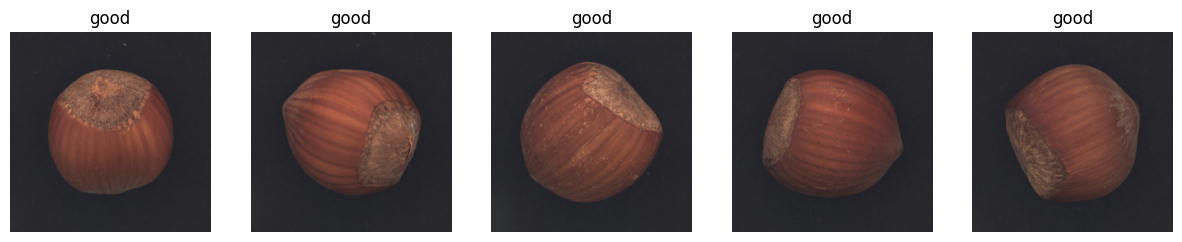

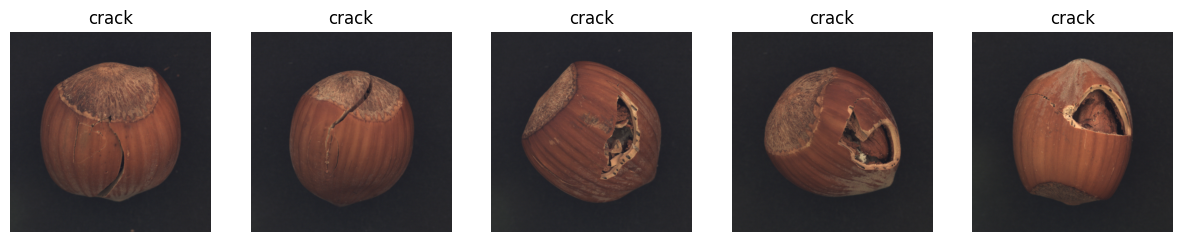

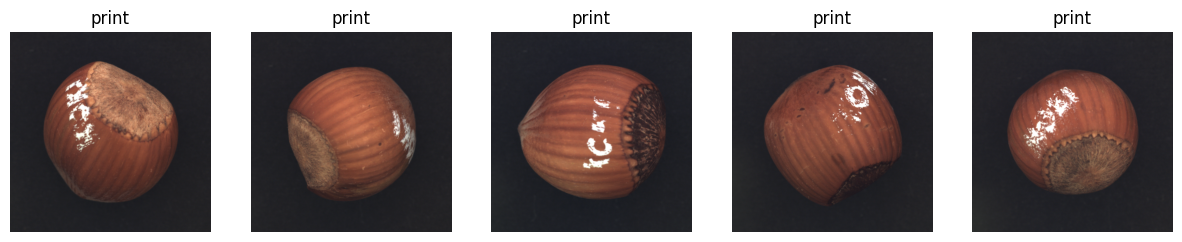

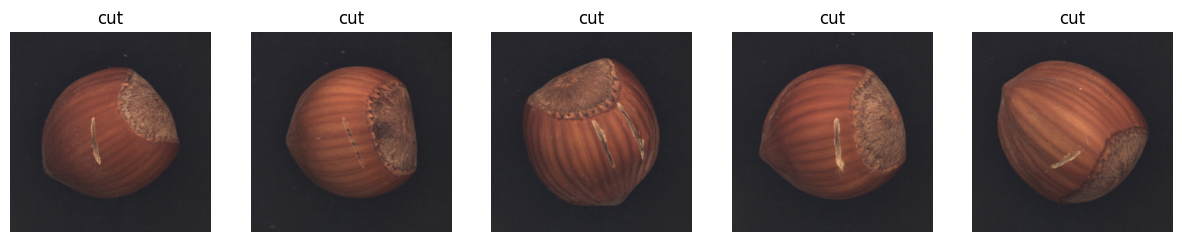

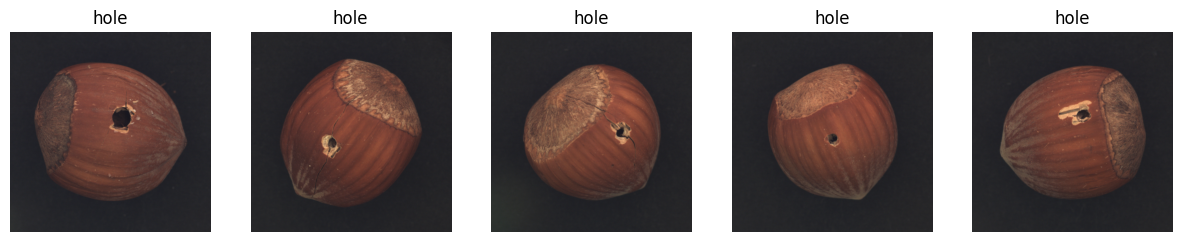

In [4]:
import os
import zipfile
import urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random

data_dir = Path("../data/mvtec/hazelnut") 

if not data_dir.exists():
    print("Downloading hazelnut...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("../data/mvtec")
    print("Done.")

# 图像展示函数
def show_samples(root, defect_type='good', num=5):
    folder = root / 'test' / defect_type
    images = list(folder.glob("*.png"))

    if len(images) == 0:
        print(f"⚠️ No images found for {defect_type}")
        return

    actual_num = min(num, len(images))
    samples = random.sample(images, actual_num)
    fig, axs = plt.subplots(1, actual_num, figsize=(15, 4))
    for ax, img_path in zip(axs, samples):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(defect_type)
        ax.axis('off')
    plt.show()

# 展示 good 图像样本
show_samples(data_dir, 'good')

# 展示缺陷类型样本
for cls in os.listdir(data_dir / 'test'):
    if cls == 'good' or cls.startswith('.'):
        continue
    show_samples(data_dir, cls)
